In [1]:
!pip3 install scikit-learn --break-system-packages

In [6]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 8760  # 365 days of hourly data

timestamps = pd.date_range(start="2024-01-01", periods=n, freq="h")

# --- Normal usage patterns ---
cpu_usage    = np.random.normal(loc=40,  scale=5,  size=n)   # % CPU
memory_usage = np.random.normal(loc=60,  scale=8,  size=n)   # % RAM
network_in   = np.random.normal(loc=200, scale=30, size=n)   # MB/hr inbound
network_out  = np.random.normal(loc=150, scale=25, size=n)   # MB/hr outbound
num_requests = np.random.normal(loc=500, scale=50, size=n)   # API calls/hr
cost         = np.random.normal(loc=2.5, scale=0.3, size=n)  # USD/hr

# --- Inject anomalies ---
# increase from 15 to 100 anomalies
# Inject 500 anomalies instead of 100
anomaly_indices = np.random.choice(n, size=500, replace=False)

cpu_usage[anomaly_indices]    += np.random.uniform(60, 80,    size=500)
memory_usage[anomaly_indices] += np.random.uniform(50, 70,    size=500)
network_in[anomaly_indices]   += np.random.uniform(500, 900,  size=500)
network_out[anomaly_indices]  += np.random.uniform(400, 700,  size=500)
num_requests[anomaly_indices] += np.random.uniform(1500, 3000,size=500)
cost[anomaly_indices]         += np.random.uniform(10, 25,    size=500)
# --- Build DataFrame ---
df = pd.DataFrame({
    "timestamp":          timestamps,
    "cpu_usage_pct":      np.clip(cpu_usage,    0, 100),
    "memory_usage_pct":   np.clip(memory_usage, 0, 100),
    "network_in_mb":      np.clip(network_in,   0, None),
    "network_out_mb":     np.clip(network_out,  0, None),
    "num_requests":       np.clip(num_requests, 0, None),
    "cost_usd":           np.clip(cost,         0, None)
})

print(df.head())
print(f"\nShape: {df.shape}")  # should be (8760, 7)

            timestamp  cpu_usage_pct  memory_usage_pct  network_in_mb  \
0 2024-01-01 00:00:00      42.483571         67.771299     203.610497   
1 2024-01-01 01:00:00      39.308678         49.637931     221.613707   
2 2024-01-01 02:00:00      43.238443         50.499575     174.242413   
3 2024-01-01 03:00:00      47.615149         64.631279     250.865475   
4 2024-01-01 04:00:00     100.000000        100.000000    1027.744167   

   network_out_mb  num_requests   cost_usd  
0      177.015530    480.943705   2.840820  
1      169.468495    534.400886   2.695422  
2      160.962654    434.591295   2.373778  
3      165.947151    442.535220   2.740849  
4      842.499627   2767.882535  13.260330  

Shape: (8760, 7)


In [7]:
from scipy import stats

df["z_score"] = np.abs(stats.zscore(df["cost_usd"]))
df["is_anomaly"] = df["z_score"] > 2.5 # threshold you can tune
df["z_score"].nlargest(5)

6396    5.702184
1993    5.680517
7794    5.663710
615     5.662444
5213    5.660493
Name: z_score, dtype: float64

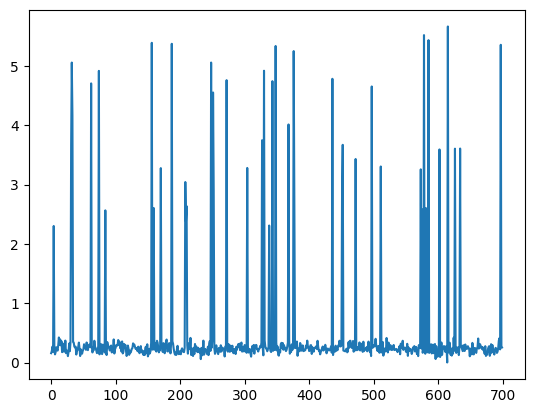

In [8]:
import matplotlib.pyplot as plt
plt.plot(df["z_score"].head(700)) 

In [10]:
import sys
!{sys.executable} -m pip install scikit-learn --break-system-packages
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy import stats
import numpy as np

# Step 1 — Generate z-score labels (you already have this)
df["z_score"] = np.abs(stats.zscore(df["cost_usd"]))
df["is_anomaly"] = (df["z_score"] > 2.5).astype(int)  # 1 = anomaly, 0 = normal

# Step 2 — Define features (what the model looks at) and target (what it predicts)
X = df[["cpu_usage_pct", "memory_usage_pct", "num_requests",
        "network_in_mb", "network_out_mb", "cost_usd"]].values
y = df["is_anomaly"].values  # z-score labels become the ground truth

# Step 3 — Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"Anomalies in training set: {y_train.sum()}")
print(f"Anomalies in test set    : {y_test.sum()}")

# Step 4 — Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 5 — Predict on test data
y_pred_raw = model.predict(X_test)       # gives values like 0.3, 0.7, 1.1 etc.
y_pred = (y_pred_raw > 0.5).astype(int)  # convert to 0 or 1

# Step 6 — Evaluate
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy * 100:.2f}%")
print(f"\nConfusion Matrix:")
print(f"                 Predicted Normal  Predicted Anomaly")
print(f"Actual Normal         {cm[0][0]}                {cm[0][1]}")
print(f"Actual Anomaly        {cm[1][0]}                {cm[1][1]}")

# Step 7 — See which metrics matter most
feature_names = ["cpu_usage_pct", "memory_usage_pct", "num_requests",
                 "network_in_mb", "network_out_mb", "cost_usd"]
print("\nFeature Importance (coefficients):")
for name, coef in zip(feature_names, model.coef_):
    print(f"  {name:25s}: {coef:.6f}")

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 525.3 kB/s  0:04:08a 0:00:010:00:02:04
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn]━━━━━ 2/3 [scikit-learn]
Training samples : 7008
Testing samples  : 1752
Anomalies in training set: 354
Anomalies in test set    : 88

Model Accuracy: 99.49%

Confusion Matrix:
                 Predicted Normal  Predicted Anomaly
Actual Normal         1655                9
Actual Anomaly        0                88

Feature Importance (coefficients):
  cpu_usage_pct            : 0.000264
  memory_usage_pct         : 0.000043
  num_requests             : 0.000049
  network_in_mb            : 0.000008
  network_out_mb           : 0.000045
  cost_usd                 : 0.040652
